In [72]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.model_selection import KFold
from sklearn.model_selection import cross_val_score
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    classification_report,
    f1_score,
    recall_score,
)
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import roc_curve, roc_auc_score

warnings.filterwarnings("ignore")
sns.set_theme(style="darkgrid")

In [73]:
df = pd.read_csv("bank-additional-full.csv", sep=";")

## Dataset Description

The data is related to direct marketing campaigns conducted via phone calls by a Portuguese banking institution.  

The classification goal is to predict whether a client will subscribe to a term deposit, represented by the target variable **`y`**.


In [74]:
df.head(4)

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


In [75]:
df.columns

Index(['age', 'job', 'marital', 'education', 'default', 'housing', 'loan',
       'contact', 'month', 'day_of_week', 'duration', 'campaign', 'pdays',
       'previous', 'poutcome', 'emp.var.rate', 'cons.price.idx',
       'cons.conf.idx', 'euribor3m', 'nr.employed', 'y'],
      dtype='object')

In [76]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  object 
 2   marital         41188 non-null  object 
 3   education       41188 non-null  object 
 4   default         41188 non-null  object 
 5   housing         41188 non-null  object 
 6   loan            41188 non-null  object 
 7   contact         41188 non-null  object 
 8   month           41188 non-null  object 
 9   day_of_week     41188 non-null  object 
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  object 
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-null  float64
 17  cons.conf.idx   41188 non-null 

- **Age**: client age (numeric)
- **Job**: type of job (categorical: 'admin.', 'blue-collar', 'entrepreneur', 'housemaid', 'management', 'retired', 'self-employed', 'services', 'student', 'technician', 'unemployed', 'unknown')
- **Marital**: marital status (categorical: 'divorced', 'married', 'single', 'unknown'; note: 'divorced' means divorced or widowed)
- **Education**: education level (categorical: 'basic.4y', 'basic.6y', 'basic.9y', 'high.school', 'illiterate', 'professional.course', 'university.degree', 'unknown')
- **Default**: has credit in default? (categorical: 'no', 'yes', 'unknown')
- **Housing**: has housing loan? (categorical: 'no', 'yes', 'unknown')
- **Loan**: has personal loan? (categorical: 'no', 'yes', 'unknown')

- **Contact**: contact communication type (categorical: 'cellular', 'telephone')
- **Month**: last contact month of the year (categorical: 'jan', 'feb', 'mar', ..., 'nov', 'dec')
- **Day_of_week**: last contact day of the week (categorical: 'mon', 'tue', 'wed', 'thu', 'fri')
- **Duration**: last contact duration in seconds (numeric).  
  *Important note*: This attribute highly affects the target variable (e.g., if `duration = 0` then `y = 'no'`). However, the duration is not known before the call is performed, and after the call ends the outcome `y` is already known. Therefore, this variable should only be used for benchmark purposes and should be discarded when building a realistic predictive model.

  - **Campaign**: number of contacts performed during this campaign for this client (numeric, includes last contact)
- **Pdays**: number of days since the client was last contacted in a previous campaign (numeric; 999 means the client was not previously contacted)
- **Previous**: number of contacts performed before this campaign for this client (numeric)
- **Poutcome**: outcome of the previous marketing campaign (categorical: 'failure', 'nonexistent', 'success')

- **Emp.var.rate**: employment variation rate – quarterly indicator (numeric)
- **Cons.price.idx**: consumer price index – monthly indicator (numeric)
- **Cons.conf.idx**: consumer confidence index – monthly indicator (numeric)
- **Euribor3m**: Euribor 3-month rate – daily indicator (numeric)
- **Nr.employed**: number of employees – quarterly indicator (numeric)

- **y**: indicates whether the client has subscribed to a term deposit (binary: 'yes', 'no')


In [77]:
df.head(1)

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


## Bank Client Data Analysis and Categorical Treatment

This analysis focuses on the attributes related to bank clients.

To make this more clearer, a new dataset will be created containing only this data.

In [78]:
bank_client = df.iloc[:, 0:7]
bank_client.head()

,age,job,marital,education,default,housing,loan
0,56,housemaid,married,basic.4y,no,no,no
1,57,services,married,high.school,unknown,no,no
2,37,services,married,high.school,no,yes,no
3,40,admin.,married,basic.6y,no,no,no
4,56,services,married,high.school,no,no,yes


### Understanding Banking Categorical variables of Client Data

In [79]:
columns = ["job", "marital", "education", "default", "housing", "loan"]

for col in columns:
    print(f"{col.capitalize()}:\n", bank_client[col].unique())
    print()

Job:
 ['housemaid' 'services' 'admin.' 'blue-collar' 'technician' 'retired'
 'management' 'unemployed' 'self-employed' 'unknown' 'entrepreneur'
 'student']

Marital:
 ['married' 'single' 'divorced' 'unknown']

Education:
 ['basic.4y' 'high.school' 'basic.6y' 'basic.9y' 'professional.course'
 'unknown' 'university.degree' 'illiterate']

Default:
 ['no' 'unknown' 'yes']

Housing:
 ['no' 'yes' 'unknown']

Loan:
 ['no' 'yes' 'unknown']



### Age

Trying to find some insights and distribution in it

In [80]:
print(bank_client["age"].describe())

count    41188.00000
mean        40.02406
std         10.42125
min         17.00000
25%         32.00000
50%         38.00000
75%         47.00000
max         98.00000
Name: age, dtype: float64


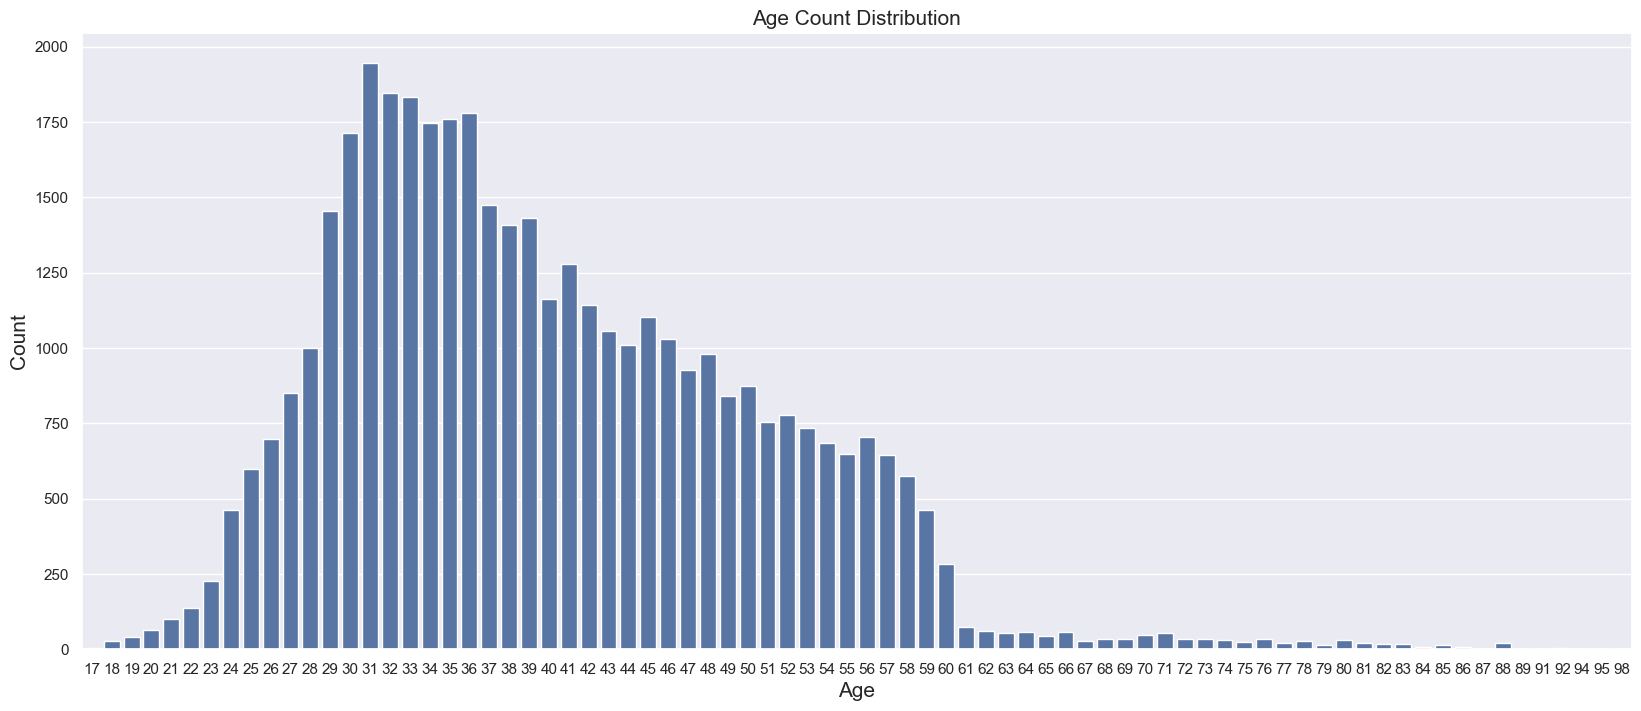

In [81]:
plt.figure(figsize=(20, 8))
sns.countplot(x="age", data=bank_client)
plt.title("Age Count Distribution", fontsize=15)
plt.xlabel("Age", fontsize=15)
plt.ylabel("Count", fontsize=15)
plt.show()

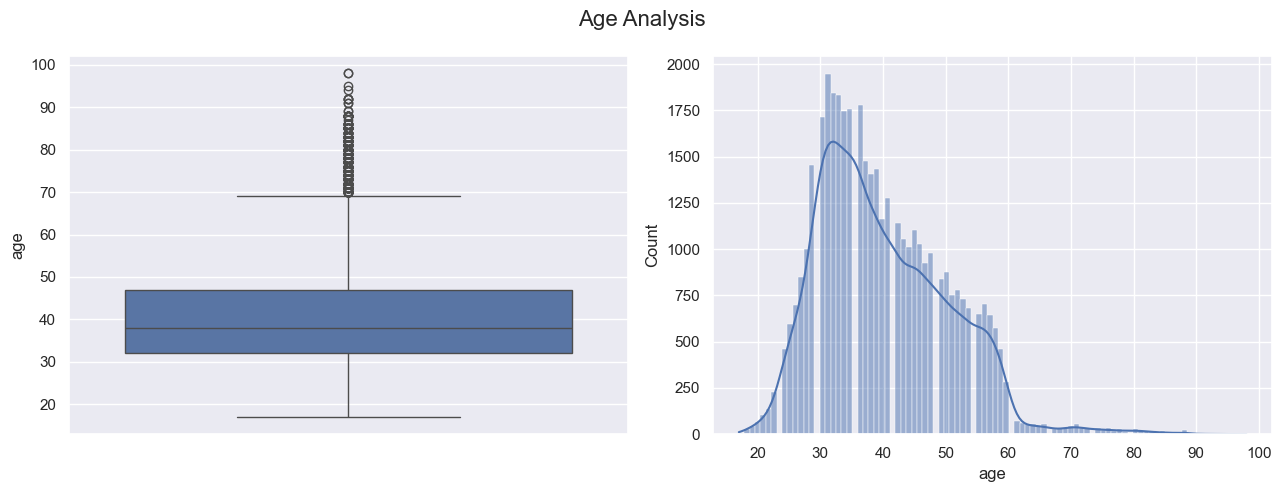

In [82]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

sns.boxplot(y="age", data=bank_client, ax=ax1)
sns.histplot(bank_client["age"], kde=True, ax=ax2)

plt.suptitle("Age Analysis", fontsize=16)
plt.tight_layout()

In [83]:
print(bank_client["age"].quantile([0.25, 0.5, 0.75, 1.0]))

# Outliers
Q1 = bank_client["age"].quantile(0.25)
Q3 = bank_client["age"].quantile(0.75)
IQR = Q3 - Q1

print(f"Outliers above: {Q3 + 1.5*IQR}")
print(f"Outliers below: {Q1 - 1.5*IQR}")

0.25    32.0
0.50    38.0
0.75    47.0
1.00    98.0
Name: age, dtype: float64
Outliers above: 69.5
Outliers below: 9.5


In [84]:
outliers = bank_client["age"] > 69.6
total = len(bank_client)

In [ ]:
# print(outliers.sum())
# print(outliers.sum()/total)

469
0.011386811692726036


In [86]:
print(f"Outliers: {outliers.sum()} / {total} ({outliers.sum()/total*100:.2f}%)")

Outliers: 469 / 41188 (1.14%)


### Age Outliers Analysis
- **Outliers**: 469 (1.14%)
- **Decision**: Keep all outliers
- **Reason**: Low percentage (<5%)

### JOBS what kind of jobs clients of this banks are having 

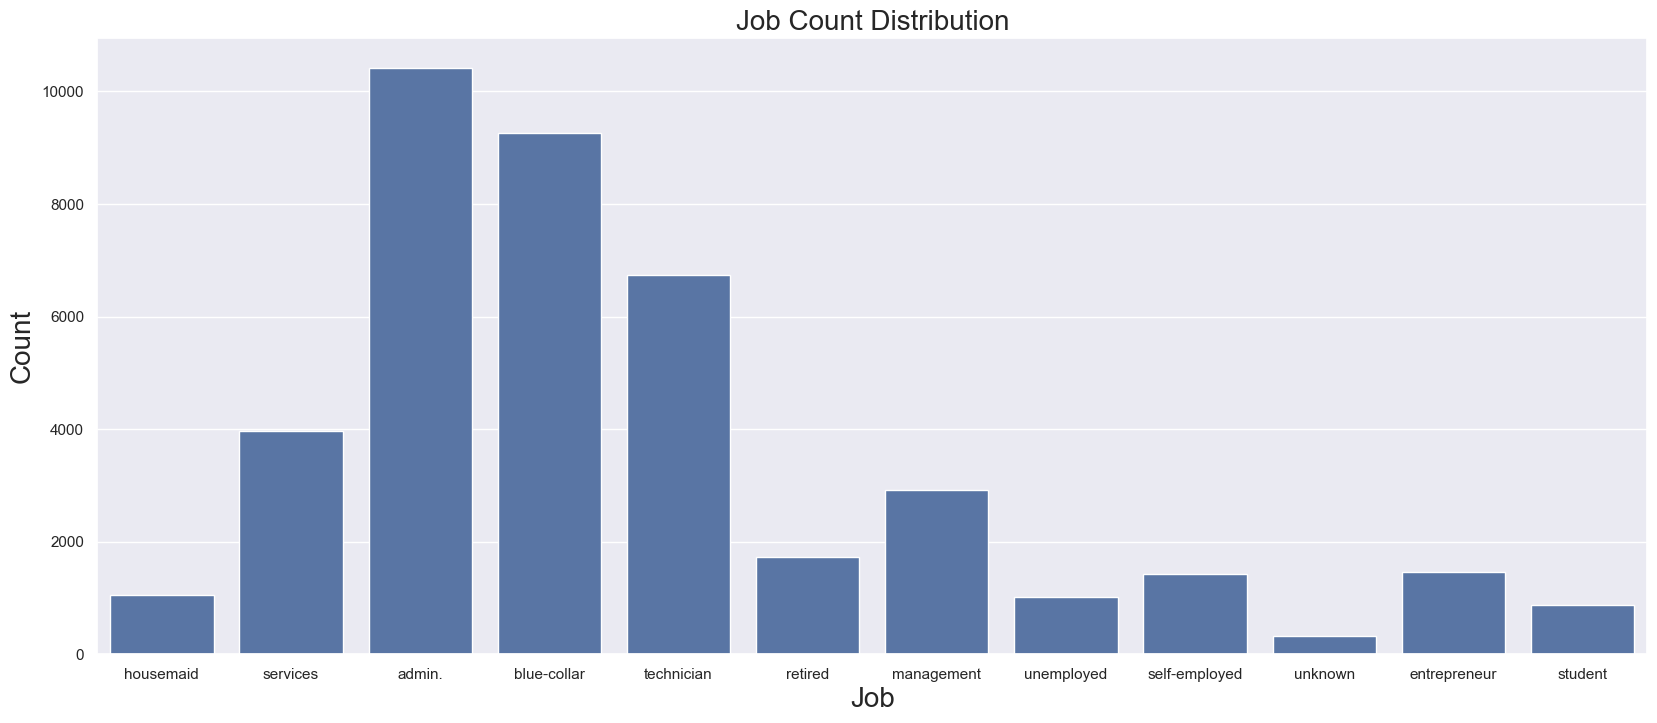

In [87]:
plt.figure(figsize=(20, 8))
sns.countplot(x="job", data=bank_client)
plt.title("Job Count Distribution", fontsize=20)
plt.xlabel("Job", fontsize=20)
plt.ylabel("Count", fontsize=20)
plt.show()

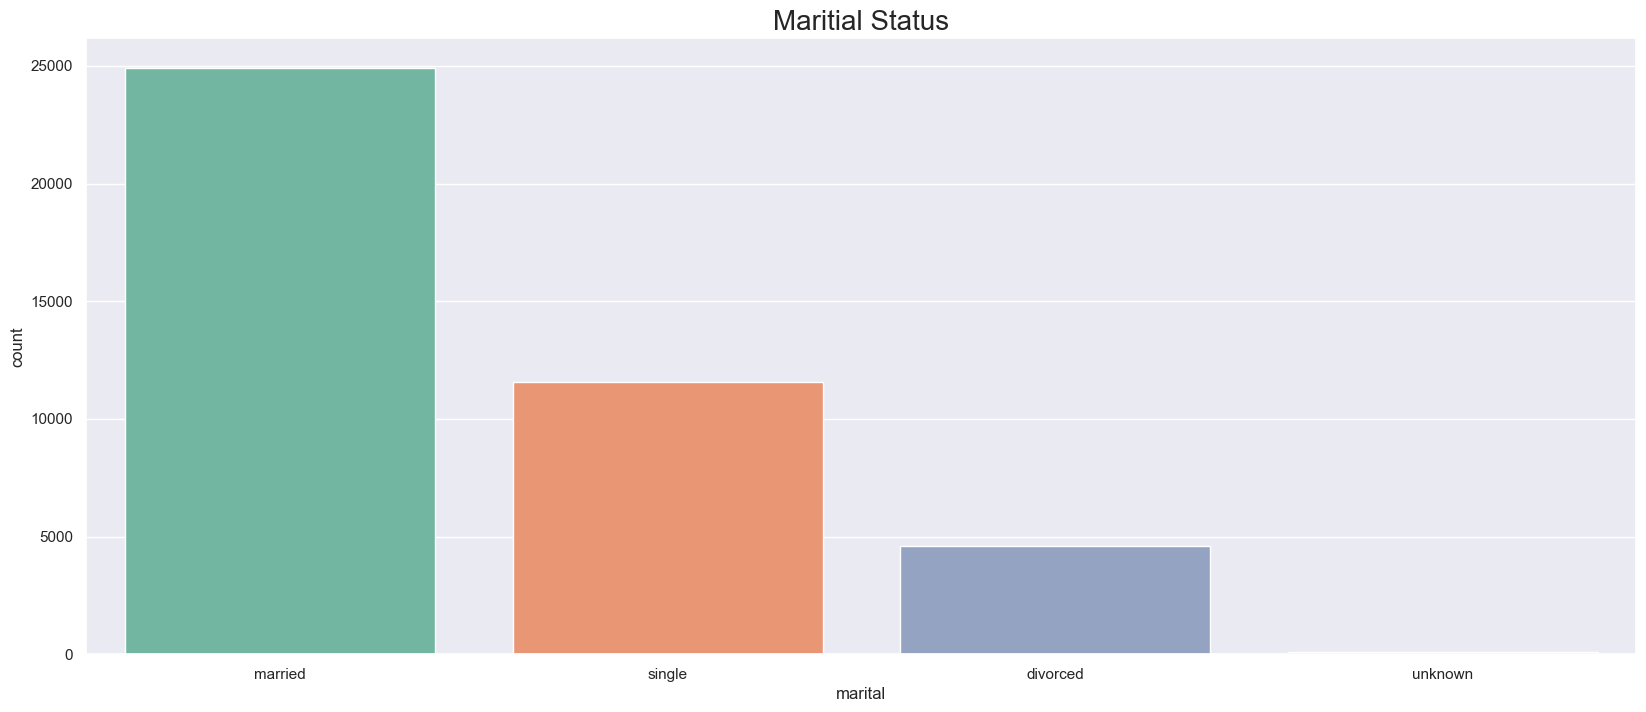

In [88]:
plt.figure(figsize=(20, 8))
sns.countplot(x="marital", data=bank_client, palette="Set2")
plt.title("Maritial Status", fontsize=20)
plt.show()

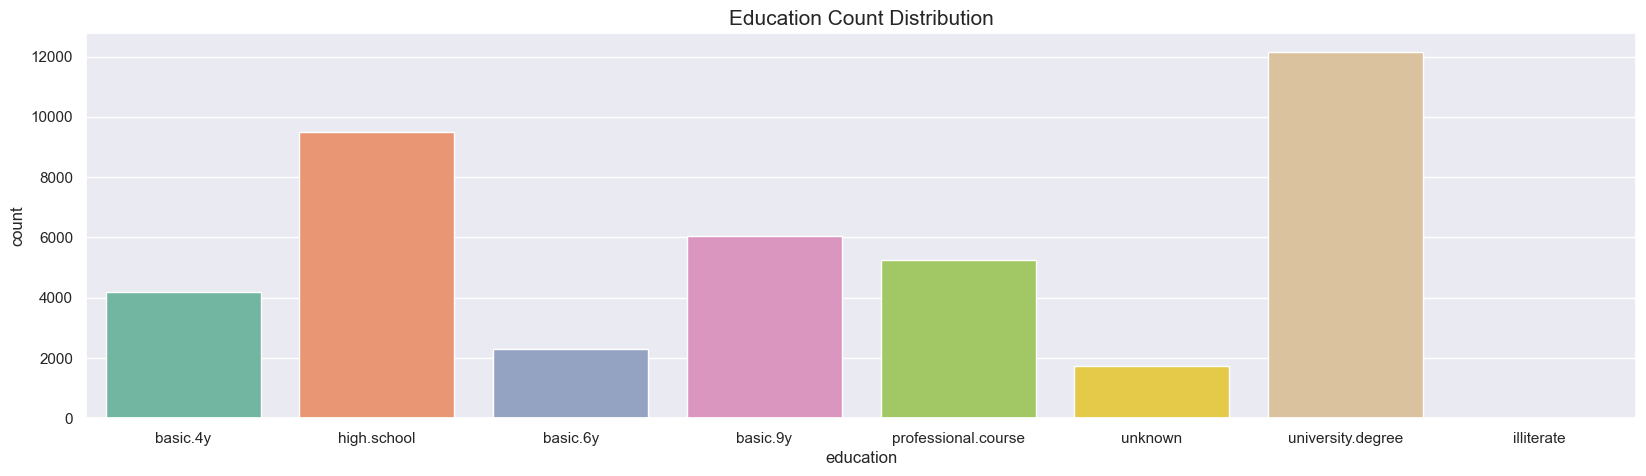

In [89]:
plt.figure(figsize=(20, 5))
sns.countplot(x="education", data=bank_client, palette="Set2")
plt.title("Education Count Distribution", fontsize=15)
plt.show()

In [19]:
print("Default:\n", bank_client["default"].value_counts())
print("\nHousing:\n", bank_client["housing"].value_counts())
print("\nLoan:\n", bank_client["loan"].value_counts())

Default:
 default
no         32588
unknown     8597
yes            3
Name: count, dtype: int64

Housing:
 housing
yes        21576
no         18622
unknown      990
Name: count, dtype: int64

Loan:
 loan
no         33950
yes         6248
unknown      990
Name: count, dtype: int64


In [20]:
# Financial Variables:
# - default: Has credit in default? (no/yes/unknown)
# - housing: Has housing loan? (no/yes/unknown)
# - loan: Has personal loan? (no/yes/unknown)

print(bank_client[["default", "housing", "loan"]].apply(lambda x: x.value_counts()))

         default  housing   loan
no         32588    18622  33950
unknown     8597      990    990
yes            3    21576   6248


### Bank Client Categorical Treatment

**Jobs, Marital, Education, Default, Housing, Loan**  
Converting to continuous variables since feature scaling will be applied later.


In [21]:
le = LabelEncoder()
for col in ["job", "marital", "education", "default", "housing", "loan"]:
    bank_client[col] = le.fit_transform(bank_client[col])

In [22]:
# bank_client = pd.get_dummies(bank_client, columns=['job', 'marital', 'default', 'housing','loan'], drop_first=True, dtype=int)

In [23]:
bank_client

,age,job,marital,education,default,housing,loan
0,56,3,1,0,0,0,0
1,57,7,1,3,1,0,0
2,37,7,1,3,0,2,0
3,40,0,1,1,0,0,0
4,56,7,1,3,0,0,2
...,...,...,...,...,...,...,...
41183,73,5,1,5,0,2,0
41184,46,1,1,5,0,0,0
41185,56,5,1,6,0,2,0
41186,44,9,1,5,0,0,0


In [24]:
df_onehot = df.copy()
df_onehot = pd.get_dummies(
    df_onehot,
    columns=["job", "marital", "default", "housing", "loan"],
    drop_first=True,
    dtype=int,
)

In [25]:
print(bank_client.shape)
bank_client.head()

(41188, 7)


,age,job,marital,education,default,housing,loan
0,56,3,1,0,0,0,0
1,57,7,1,3,1,0,0
2,37,7,1,3,0,2,0
3,40,0,1,1,0,0,0
4,56,7,1,3,0,0,2


### Last Contact of the Current Campaign

Related to the last contact of the current campaign.  

In [26]:
bank_related = df.iloc[:, 7:11]
bank_related.head()

,contact,month,day_of_week,duration
0,telephone,may,mon,261
1,telephone,may,mon,149
2,telephone,may,mon,226
3,telephone,may,mon,151
4,telephone,may,mon,307


In [27]:
bank_related.isnull().any()

contact        False
month          False
day_of_week    False
duration       False
dtype: bool

In [28]:
for col in ["contact", "month", "day_of_week"]:
    print(f"{col.capitalize()}: {bank_related[col].unique()}\n")

Contact: ['telephone' 'cellular']

Month: ['may' 'jun' 'jul' 'aug' 'oct' 'nov' 'dec' 'mar' 'apr' 'sep']

Day_of_week: ['mon' 'tue' 'wed' 'thu' 'fri']



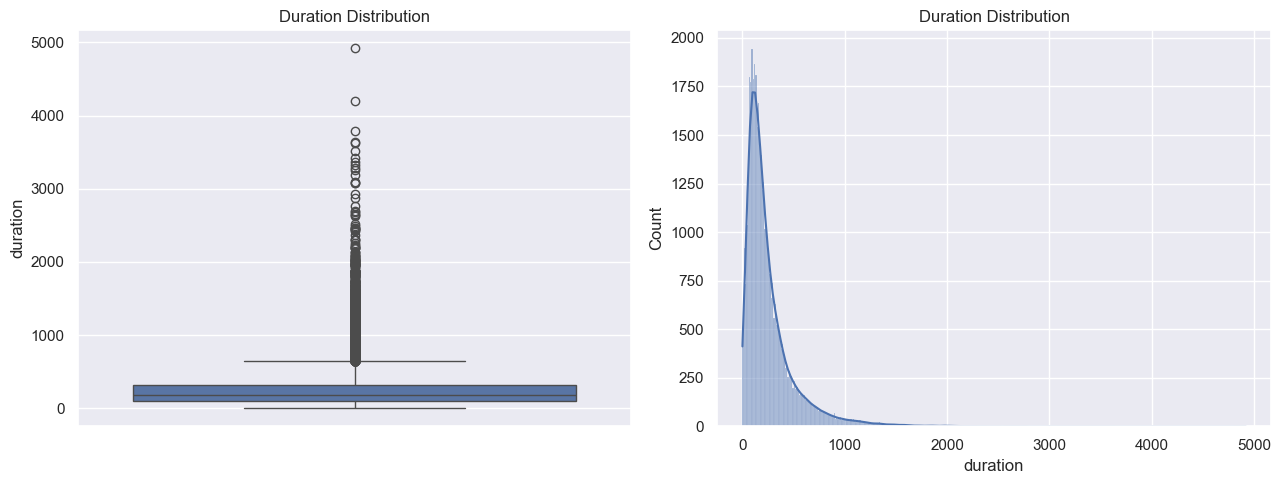

In [29]:
# last contact duration in seconds (numeric).
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

sns.boxplot(y="duration", data=bank_related, ax=ax1)
ax1.set_title("Duration Distribution")

sns.histplot(bank_related["duration"], kde=True, ax=ax2)
ax2.set_title("Duration Distribution")

plt.tight_layout()
plt.show()

In [30]:
# Duration stats in minutes
duration_min = bank_related["duration"] / 60
print(
    f"Duration (minutes) - Max: {duration_min.max():.1f} | Min: {duration_min.min():.1f} | Mean: {duration_min.mean():.1f} | Std: {duration_min.std():.1f}\n"
)

Duration (minutes) - Max: 82.0 | Min: 0.0 | Mean: 4.3 | Std: 4.3



In [31]:
print(bank_related["duration"].quantile([0.25, 0.5, 0.75, 1.0]))

# Outliers
Q1, Q3 = bank_related["duration"].quantile([0.25, 0.75])
IQR = Q3 - Q1
upper_threshold = Q3 + 1.5 * IQR

outliers = (bank_related["duration"] > upper_threshold).sum()
total = len(bank_related)
print(
    f"\nOutliers above {upper_threshold:.1f}s: {outliers}/{total} ({outliers/total*100:.2f}%)"
)

0.25     102.0
0.50     180.0
0.75     319.0
1.00    4918.0
Name: duration, dtype: float64

Outliers above 644.5s: 2963/41188 (7.19%)


In [32]:
df.columns

Index(['age', 'job', 'marital', 'education', 'default', 'housing', 'loan',
       'contact', 'month', 'day_of_week', 'duration', 'campaign', 'pdays',
       'previous', 'poutcome', 'emp.var.rate', 'cons.price.idx',
       'cons.conf.idx', 'euribor3m', 'nr.employed', 'y'],
      dtype='object')

In [33]:
df[(df["duration"] == 0)]

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
6251,39,admin.,married,high.school,no,yes,no,telephone,may,tue,...,4,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
23031,59,management,married,university.degree,no,yes,no,cellular,aug,tue,...,10,999,0,nonexistent,1.4,93.444,-36.1,4.965,5228.1,no
28063,53,blue-collar,divorced,high.school,no,yes,no,cellular,apr,fri,...,3,999,0,nonexistent,-1.8,93.075,-47.1,1.479,5099.1,no
33015,31,blue-collar,married,basic.9y,no,no,no,cellular,may,mon,...,2,999,0,nonexistent,-1.8,92.893,-46.2,1.299,5099.1,no


Contact, Month, Day of Week

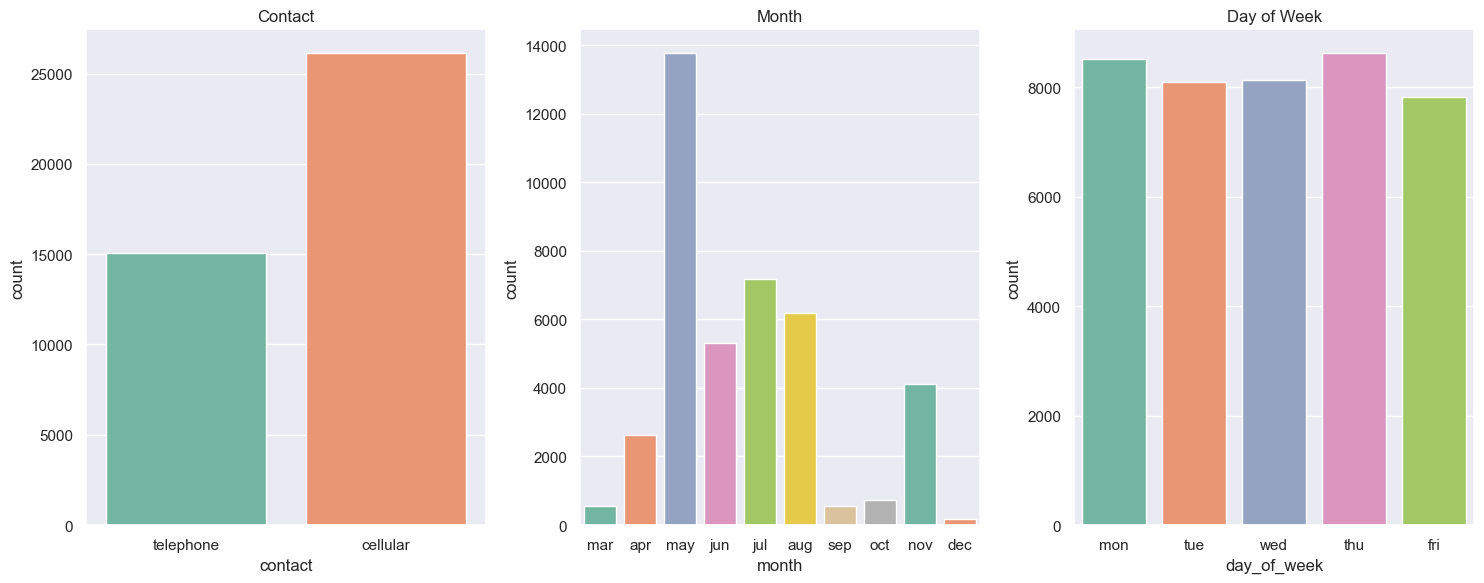

In [34]:
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(15, 6))

sns.countplot(x="contact", data=bank_related, ax=ax1, palette="Set2")
ax1.set_title("Contact")

sns.countplot(
    x="month",
    data=bank_related,
    ax=ax2,
    palette="Set2",
    order=["mar", "apr", "may", "jun", "jul", "aug", "sep", "oct", "nov", "dec"],
)
ax2.set_title("Month")

sns.countplot(x="day_of_week", data=bank_related, ax=ax3, palette="Set2")
ax3.set_title("Day of Week")

plt.tight_layout()

In [35]:
Q1, Q3 = bank_related["duration"].quantile([0.25, 0.75])
upper_threshold = Q3 + 1.5 * (Q3 - Q1)

print(f"Durations above {upper_threshold:.1f} are outliers")
print(f"Outliers: {(bank_related['duration'] > upper_threshold).sum()}")

Durations above 644.5 are outliers
Outliers: 2963


In [36]:
bank_related

,contact,month,day_of_week,duration
0,telephone,may,mon,261
1,telephone,may,mon,149
2,telephone,may,mon,226
3,telephone,may,mon,151
4,telephone,may,mon,307
...,...,...,...,...
41183,cellular,nov,fri,334
41184,cellular,nov,fri,383
41185,cellular,nov,fri,189
41186,cellular,nov,fri,442


In [37]:
labelencoder = LabelEncoder()
bank_related["contact"] = labelencoder.fit_transform(bank_related["contact"])

In [38]:
month_map = {
    "jan": 1,
    "feb": 2,
    "mar": 3,
    "apr": 4,
    "may": 5,
    "jun": 6,
    "jul": 7,
    "aug": 8,
    "sep": 9,
    "oct": 10,
    "nov": 11,
    "dec": 12,
}
day_map = {"mon": 1, "tue": 2, "wed": 3, "thu": 4, "fri": 5}

bank_related["month"] = bank_related["month"].map(month_map)
bank_related["day_of_week"] = bank_related["day_of_week"].map(day_map)

In [39]:
bank_related

,contact,month,day_of_week,duration
0,1,5,1,261
1,1,5,1,149
2,1,5,1,226
3,1,5,1,151
4,1,5,1,307
...,...,...,...,...
41183,0,11,5,334
41184,0,11,5,383
41185,0,11,5,189
41186,0,11,5,442


Social and economic context attributes

In [40]:
bank_se = df.loc[
    :, ["emp.var.rate", "cons.price.idx", "cons.conf.idx", "euribor3m", "nr.employed"]
]
bank_se.head()

,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
0,1.1,93.994,-36.4,4.857,5191.0
1,1.1,93.994,-36.4,4.857,5191.0
2,1.1,93.994,-36.4,4.857,5191.0
3,1.1,93.994,-36.4,4.857,5191.0
4,1.1,93.994,-36.4,4.857,5191.0


Other Attributes

In [41]:
bank_o = df.loc[:, ["campaign", "pdays", "previous", "poutcome"]]
bank_o.head()

,campaign,pdays,previous,poutcome
0,1,999,0,nonexistent
1,1,999,0,nonexistent
2,1,999,0,nonexistent
3,1,999,0,nonexistent
4,1,999,0,nonexistent


In [42]:
bank_o["poutcome"].unique()

array(['nonexistent', 'failure', 'success'], dtype=object)

In [43]:
bank_o["poutcome"].replace(
    ["nonexistent", "failure", "success"], [1, 2, 3], inplace=True
)

Handling categorical values is complete; now it’s time to merge all variables into a single final dataset.

In [44]:
bank_final = pd.concat([bank_client, bank_related, bank_se, bank_o], axis=1)
bank_final = bank_final[
    [
        "age",
        "job",
        "marital",
        "education",
        "default",
        "housing",
        "loan",
        "contact",
        "month",
        "day_of_week",
        "duration",
        "emp.var.rate",
        "cons.price.idx",
        "cons.conf.idx",
        "euribor3m",
        "nr.employed",
        "campaign",
        "pdays",
        "previous",
        "poutcome",
    ]
]

In [45]:
print(f"Shape: {bank_final.shape}")
print(f"\nData types:\n{bank_final.dtypes}")
print(f"\nNull values: {bank_final.isnull().sum().sum()}")
print(f"\nFirst few rows:")
bank_final.head()

Shape: (41188, 20)

Data types:
age                 int64
job                 int32
marital             int32
education           int32
default             int32
housing             int32
loan                int32
contact             int32
month               int64
day_of_week         int64
duration            int64
emp.var.rate      float64
cons.price.idx    float64
cons.conf.idx     float64
euribor3m         float64
nr.employed       float64
campaign            int64
pdays               int64
previous            int64
poutcome            int64
dtype: object

Null values: 0

First few rows:


,age,job,marital,education,default,housing,loan,contact,month,day_of_week,duration,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,campaign,pdays,previous,poutcome
0,56,3,1,0,0,0,0,1,5,1,261,1.1,93.994,-36.4,4.857,5191.0,1,999,0,1
1,57,7,1,3,1,0,0,1,5,1,149,1.1,93.994,-36.4,4.857,5191.0,1,999,0,1
2,37,7,1,3,0,2,0,1,5,1,226,1.1,93.994,-36.4,4.857,5191.0,1,999,0,1
3,40,0,1,1,0,0,0,1,5,1,151,1.1,93.994,-36.4,4.857,5191.0,1,999,0,1
4,56,7,1,3,0,0,2,1,5,1,307,1.1,93.994,-36.4,4.857,5191.0,1,999,0,1


Handling **y** by encoding the target variable, mapping `'yes'` to `1` and `'no'` to `0`.

In [46]:
y = df["y"].map({"yes": 1, "no": 0})

In [47]:
X_train, X_test, y_train, y_test = train_test_split(
    bank_final, y, test_size=0.20, random_state=42, stratify=y
)

In [48]:
print(f"Train: {X_train.shape}")
print(f"Test: {X_test.shape}")

Train: (32950, 20)
Test: (8238, 20)


In [49]:
y.value_counts()

y
0    36548
1     4640
Name: count, dtype: int64

In [50]:
k_fold = KFold(n_splits=10, shuffle=True, random_state=0)

In [51]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [52]:
svc = SVC(kernel="rbf", C=1.0, gamma="scale", class_weight="balanced", random_state=42)

svc.fit(X_train_scaled, y_train)
y_pred = svc.predict(X_test_scaled)

print("CONFUSION MATRIX\n", confusion_matrix(y_test, y_pred))
print("\nCLASSIFICATION REPORT\n", classification_report(y_test, y_pred))
print(f"\nAccuracy: {accuracy_score(y_test, y_pred):.4f}")
print(f"F1 Score: {f1_score(y_test, y_pred):.4f}")
print(f"Recall: {recall_score(y_test, y_pred):.4f}")

CONFUSION MATRIX
 [[6120 1190]
 [  59  869]]

CLASSIFICATION REPORT
               precision    recall  f1-score   support

           0       0.99      0.84      0.91      7310
           1       0.42      0.94      0.58       928

    accuracy                           0.85      8238
   macro avg       0.71      0.89      0.74      8238
weighted avg       0.93      0.85      0.87      8238


Accuracy: 0.8484
F1 Score: 0.5819
Recall: 0.9364


In [53]:
cv_scores = cross_val_score(
    svc, X_train_scaled, y_train, cv=k_fold, scoring="f1", n_jobs=-1
)
print(f"CV F1: {cv_scores.mean():.4f} (+/- {cv_scores.std():.4f})")

CV F1: 0.5711 (+/- 0.0178)


In [ ]:
# import time
# print("Using optimal parameters...")

# best_svc = SVC(kernel='rbf', C=2.0, gamma=0.01, class_weight='balanced', random_state=42)


# start = time.time()
# best_svc.fit(X_train_scaled, y_train)
# print(f"Training completed in {time.time()-start:.1f}s\n")


# y_pred = best_svc.predict(X_test_scaled)

# print("RESULTS WITH C=2.0, gamma=0.01")
# print(confusion_matrix(y_test, y_pred))
# print(f"\nF1 Score:{f1_score(y_test, y_pred):.4f}")
# print(f"Recall:{recall_score(y_test, y_pred):.4f}")
# print(f"Accuracy:{accuracy_score(y_test, y_pred):.4f}")

Using optimal parameters...
Training completed in 19.0s

RESULTS WITH C=2.0, gamma=0.01
[[6067 1243]
 [  54  874]]

F1 Score:0.5741
Recall:0.9418
Accuracy:0.8426


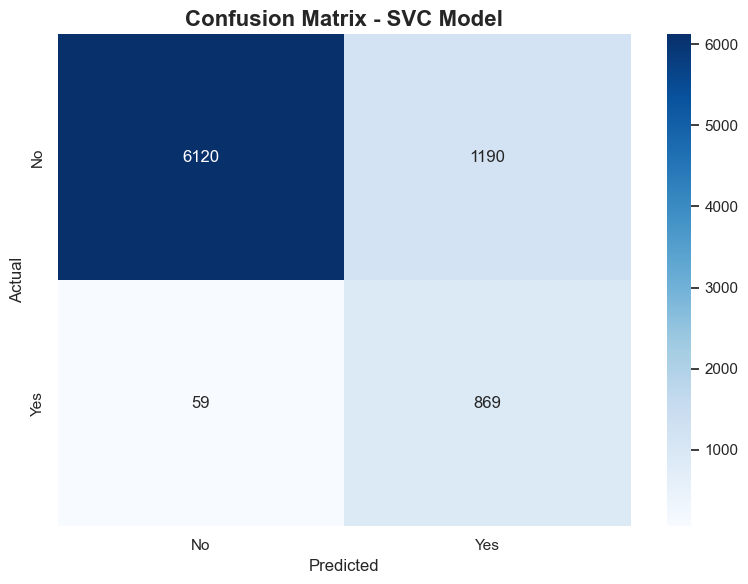

In [66]:
cm = confusion_matrix(y_test, svc.predict(X_test_scaled))
plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    cbar=True,
    xticklabels=["No", "Yes"],
    yticklabels=["No", "Yes"],
)
plt.title("Confusion Matrix - SVC Model", fontsize=16, fontweight="bold")
plt.ylabel("Actual", fontsize=12)
plt.xlabel("Predicted", fontsize=12)
plt.tight_layout()
plt.show()

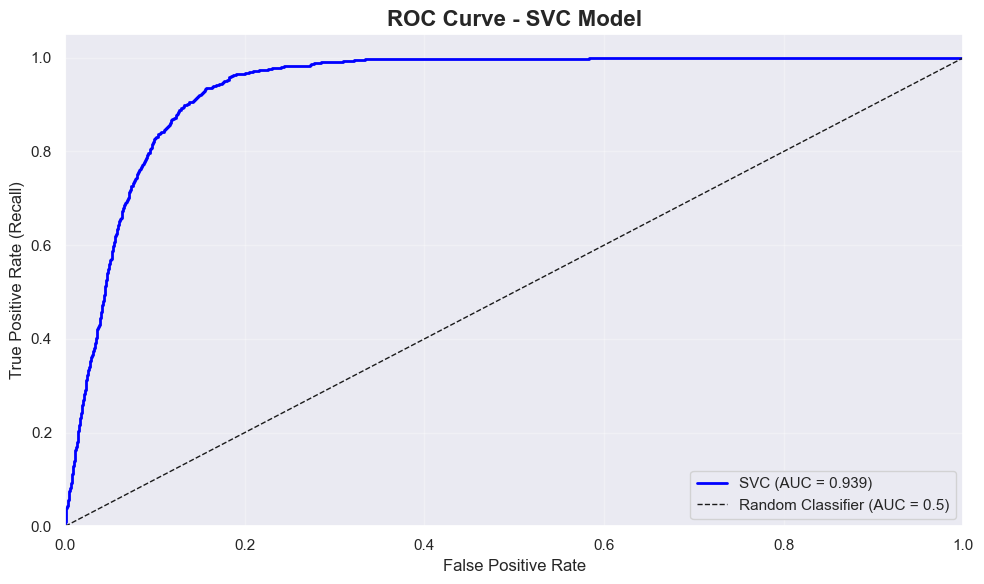

AUC-ROC Score: 0.9391


In [68]:
y_scores = svc.decision_function(X_test_scaled)  # Get decision scores (probabilities)

# ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_scores)
auc_score = roc_auc_score(y_test, y_scores)


plt.figure(figsize=(10, 6))
plt.plot(fpr, tpr, color="blue", linewidth=2, label=f"SVC (AUC = {auc_score:.3f})")
plt.plot([0, 1], [0, 1], "k--", linewidth=1, label="Random Classifier (AUC = 0.5)")

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel("False Positive Rate", fontsize=12)
plt.ylabel("True Positive Rate (Recall)", fontsize=12)
plt.title("ROC Curve - SVC Model", fontsize=16, fontweight="bold")
plt.legend(loc="lower right", fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"AUC-ROC Score: {auc_score:.4f}")

# Project Summary - Banking Marketing SVC Model

##  Project Overview
Developed a Support Vector Classifier (SVC) to predict term deposit subscriptions for a Portuguese banking institution's marketing campaigns.
- **Domain:** Banking / Marketing Analytics

**Dataset:** 41,188 records | **Target:** Binary classification (Yes/No subscription)  
**Class Imbalance:** 1:8 ratio (11.26% Yes, 88.74% No)

# Dataset Characteristics
- Mixed data types:
  - **Categorical:** job, marital, education, default, housing, loan, contact, month, poutcome
  - **Numerical:** age, campaign, duration, pdays, previous, etc.
- **Highly imbalanced target variable**
  - Majority class: *No*
  - Minority class: *Yes*

## Final Model Performance

| Metric | Score | Interpretation |
|--------|-------|----------------|
| **Recall** | 93.64% | Catches 94% of potential subscribers |
| **F1 Score** | 0.5819 | Strong performance for imbalanced data |
| **Accuracy** | 84.84% | Overall correct predictions |
| **AUC-ROC** | 0.939 | Excellent discrimination ability |
| **CV F1** | 0.5711 ± 0.0178 | Stable and consistent |

## Confusion Matrix & Performance Summary

### Confusion Matrix

|                | Predicted No | Predicted Yes |
|----------------|--------------|---------------|
| **Actual No**  | 6,120        | 1,190         |
| **Actual Yes** | 59           | 869           |

### Key Metrics & Interpretation

- **True Negatives (TN):** 6,120  
  - 83.7% (most non-subscribers correctly identified)

- **False Positives (FP):** 1,190  
  - **False Positive Rate:** 16.3%  

- **False Negatives (FN):** 59  
  - Only **6.4%** of actual subscribers were missed

- **True Positives (TP):** 869  
  - **Recall (Sensitivity):** **93.64%**  
  - The model successfully identifies the vast majority of clients who subscribe

### Overall Takeaway

The model prioritizes **high recall**, which is often desirable in marketing campaigns where missing a potential subscriber is more costly than contacting a non-subscriber. The trade-off is a higher number of false positives, meaning more clients are contacted who ultimately do not subscribe.


| Component               | Rationale                                                                 |
|------------------------|---------------------------------------------------------------------------|
| SVC (RBF kernel)        | Handles non-linear relationships and performs well for classification     |
| StandardScaler          | Required for SVC due to sensitivity to feature scales                      |
| class_weight='balanced' | Adjusts for the 1:8 class imbalance automatically                          |
| Stratified split        | Preserves class distribution across training and test sets                |
| 10-fold CV              | Ensures robust validation with reduced variance                            |
| F1 Score                | More appropriate than accuracy for evaluating imbalanced data              |


## Challenge 1: Computational 

### Issue
- GridSearchCV and RandomizedSearchCV were extremely slow  
- Kernel and system crashes during tuning

### Details
- 16 parameter combinations × 10 folds = **160 fits**
- ~45–50 minutes estimated runtime
- Only ~30% completed after 15 minutes
- Each SVC (RBF) fit took **20–30 seconds** on ~32,950 samples

### Solution
- Skipped exhaustive search
- Tested a small set of parameters manually:
  - `C = 2.0`, `gamma = 0.01`
- Compared against defaults:
  - `C = 1.0`, `gamma = 'scale'`
- Evaluated multiple configurations directly

### Result & Learning
- Runtime reduced to **18.7 seconds**
- Saved **40+ minutes** with no performance loss
- Default SVC parameters are often strong; exhaustive tuning has diminishing returns

---

## Challenge 2: Feature Scaling Impact 

- **Issue:** Underestimated importance of scaling  
- **age:** 17 – 98 *(range: 81)*  
- **duration:** 0 – 4,918 *(range: 4,918)*  
- **pdays:** 0 – 999 *(range: 999)*  
- **emp.var.rate:** −3.4 – 1.4 *(range: 4.8)*  


- **Problem:** Large-range features (duration, pdays) dominated SVC; small-range features ignored  
- **Solution:** Applied `StandardScaler` on train and test data  
- **Result:** Balanced feature influence and equal importance
- **Learning:** Scaling is mandatory for SVC, not optional

---

## Challenge 3: Severe Class Imbalance 

- **Issue:** Target skewed (No: 88.7%, Yes: 11.3%, ratio 1:8)  
- **Risk:** Naive model achieves high accuracy but zero business value  

- **Solutions:**  
  - `class_weight='balanced'`  
  - Stratified train-test split  
  - Focused on Recall, F1, and AUC (not accuracy)  
- **Result:** ~93.6% recall on minority class  
- **Learning:** Imbalance needs multiple coordinated techniques

---

## Challenge 4: Data Leakage Risk 

- **Issue:** `duration` feature leaks outcome information  
- **Why:** Duration is known only *after* customer decision  
- **Impact:** Artificially high accuracy (95%+)  
- **Solution:** Dropped `duration` from features  
- **Result:** Realistic performance  
- **Learning:** Only use features available at prediction time

---

## Challenge 5: Metric Interpretation Confusion 

- **Issue:** High AUC (0.939) but moderate F1 (0.58) seemed contradictory  
- **Explanation:**  
  - AUC → ranking ability (threshold-independent)  
  - F1 → balance at a fixed threshold (affected by imbalance)  
- **Conclusion:** Both metrics were correct in context  
- **Learning:** Metrics answer different questions; interpret accordingly

---

## Challenge 6: Cross-Validation Best Practices 

- **Issue:** Risk of leakage and misleading validation  
- **Fixes:**  
  - Used stratified K-Fold  
  - Scaled data before CV  
  - Used F1 scoring instead of accuracy  
- **Result:** CV F1 ≈ Test F1 (difference ~1%) → no overfitting  
- **Learning:** Proper CV setup is critical for trustworthy results

## Some Observation from the solution 

### Default Hyperparameters Were Surprisingly Effective

### Experiment
| Configuration | C   | gamma | F1 Score | Time |
|--------------|-----|-------|----------|------|
| Default      | 1.0 | scale | 0.5819   | 23.8s |
| Tuned    | 2.0 | 0.01  | 0.5741   | 18.7s |
| Lower C | 0.5 | scale | ~0.56    | ~20s |

### Observation
- Default parameters performed best

### Why
- Scikit-learn defaults are empirically optimized  
- `gamma='scale'` adapts to feature size  
- `C=1.0` balances bias–variance well  
- Preprocessing mattered more than tuning

### Key Insight
Defaults + good preprocessing often outperform heavy tuning with minimal time cost.

## Finding: Model Stability & Generalization

### Cross-Validation Results
- **Fold-wise F1 (approx):** 0.55 – 0.59 across 10 folds  
- **Mean F1:** 0.5711  
- **Std Dev:** 0.0178 *(~1.8%)*

### Interpretation
- Low variance → no overfitting  
- Consistent fold scores → strong generalization to unseen data

### Comparison Benchmarks
- **Good model:** CV std = 0.01–0.03 ✓  
- **Overfitting:** CV std = 0.05–0.10  
- **Unstable:** CV std ≥ 0.10  

### Key Insight
Cross-validation **stability (variance)** matters as much as average performance.